# SHL Hiring Assessment 2026 — Grammar Scoring Engine (v4)

**Task:** predict a continuous MOS grammar score (0–5) from a 45–60 s speech clip (769 train / 216 test clips).
**Metrics:** RMSE and Pearson correlation.

## Approach in brief
Human grammar ratings depend on *what is said* **and** *how it is delivered*. Development showed that the **audio** representation carries most of the signal, so v4 uses **three complementary audio views** next to the text pipeline:

| View | Model | Representation |
|---|---|---|
| Audio 1 | WavLM-base-plus | mean + std pooling of layers 4, 8, 12 |
| Audio 2 | Whisper-small **encoder** | mean + std pooling of layers 6, 9, 12 over valid frames |
| Audio 3 | WavLM-large | mean + std pooling of layers 8, 16, 24 |
| Text | Whisper-small transcript → handcrafted + GPT-2 perplexity + LanguageTool + spaCy features, MPNet embeddings, fine-tuned DeBERTa-v3 |

Every view feeds Ridge / SVR heads trained with the **same 5 folds**; out-of-fold (OOF) predictions are combined by a **non-negative linear stacker** that also calibrates the score scale.

## What changed in v4 (vs v3)
1. **Multimodal Ridge fixed:** text block uses raw embeddings × weight (as in v2) instead of standardising them first (which over-weighted text ~25×); block weights are chosen by a small CV sweep.
2. **Two extra audio views** (Whisper encoder, WavLM-large) + a combined all-audio head.
3. **Cleaner ablations:** every model belongs to exactly one group (`features`, `text`, `audio_*`, `multimodal`, `finetune`).
4. **Uncertainty:** bootstrap confidence intervals on the stack's CV RMSE / Pearson, so small differences are not over-interpreted.
5. **Robust caching:** transcript-dependent caches are keyed by a transcript hash (no stale features), caches are found in attached inputs, and DeBERTa predictions are cached.
6. Fixed Markdown table rendering, seeded Whisper fallback sampling, and an output-format check against `sample_submission.csv`.

**Setup:** Kaggle GPU (T4), Internet on, competition data attached under *Input*. To skip the slow steps, attach the **output of a previous run** as an extra input (*Add Input → Your Work*): transcripts and audio embeddings are reused automatically.

## 1. Setup and data discovery

In [1]:
import os, re, math, time, zlib, hashlib, warnings, subprocess, sys
from collections import defaultdict
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from IPython.display import Markdown, display
warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
sns.set_theme(style="whitegrid")

# ---- switches (set to False to skip heavy parts) ----
USE_WAVLM_BASE  = True   # ~10 min on a T4 (cached after first run)
USE_WHISPER_ENC = True   # ~5-8 min (estimate)
USE_WAVLM_LARGE = True   # ~20-30 min (estimate); set False for a faster run
USE_FINETUNE    = True   # DeBERTa, 5 folds, ~6 min
WORK = "/kaggle/working"

import torch, librosa
GPU = torch.cuda.is_available()
DEVICE = 0 if GPU else -1
dev_str = "cuda" if GPU else "cpu"
print("GPU available:", GPU)
SR = 16000

GPU available: True


In [2]:
# ---- Locate competition files. Train and test folders contain files with the SAME names, so keep them per-folder. ----
ROOT = "/kaggle/input"
csv_paths, by_dir, input_files = {}, defaultdict(dict), {}
for dirpath, _, files in os.walk(ROOT):
    for f in files:
        full = os.path.join(dirpath, f)
        if f in ("train.csv", "test.csv", "sample_submission.csv"):
            csv_paths[f] = full
        elif f.lower().endswith(".wav"):
            by_dir[dirpath][f] = full
        else:
            input_files[f] = full          # candidate caches from attached previous runs
for d, m in by_dir.items():
    print(len(m), "wav |", d)

train = pd.read_csv(csv_paths["train.csv"])
test = pd.read_csv(csv_paths["test.csv"])

def best_dir(names, exclude=None):
    names = set(names)
    cands = [d for d in by_dir if d != exclude]
    return max(cands, key=lambda d: (len(names & set(by_dir[d])), -abs(len(by_dir[d]) - len(names))))

train_dir = best_dir(train.filename)
test_dir = best_dir(test.filename, exclude=train_dir)
print("train audio dir:", train_dir); print("test audio dir :", test_dir)
train["path"] = train.filename.map(by_dir[train_dir])
test["path"] = test.filename.map(by_dir[test_dir])
assert train.path.notna().all() and test.path.notna().all(), "audio files missing"

all_df = pd.concat([train.assign(split="train"), test.assign(split="test")], ignore_index=True)
tr_mask = (all_df.split == "train").values
te_mask = ~tr_mask
y = all_df.loc[tr_mask, "label"].values.astype(float)
print(all_df.shape, "| train:", tr_mask.sum(), "| test:", te_mask.sum())

# ---- cache helpers: look in /kaggle/working first, then in attached inputs ----
def cache_path(name):
    p = os.path.join(WORK, name)
    return p if os.path.exists(p) else input_files.get(name)

def load_csv_cache(name, n=None):
    p = cache_path(name)
    if p is None: return None
    try:
        d = pd.read_csv(p)
        return d if (n is None or len(d) == n) else None
    except Exception:
        return None

def load_npy_cache(name, n=None):
    p = cache_path(name)
    if p is None: return None
    try:
        a = np.load(p)
        return a if (n is None or a.shape[0] == n) else None
    except Exception:
        return None

216 wav | /kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test
769 wav | /kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/train
train audio dir: /kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/train
test audio dir : /kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test
(985, 4) | train: 769 | test: 216


## 2. Label analysis

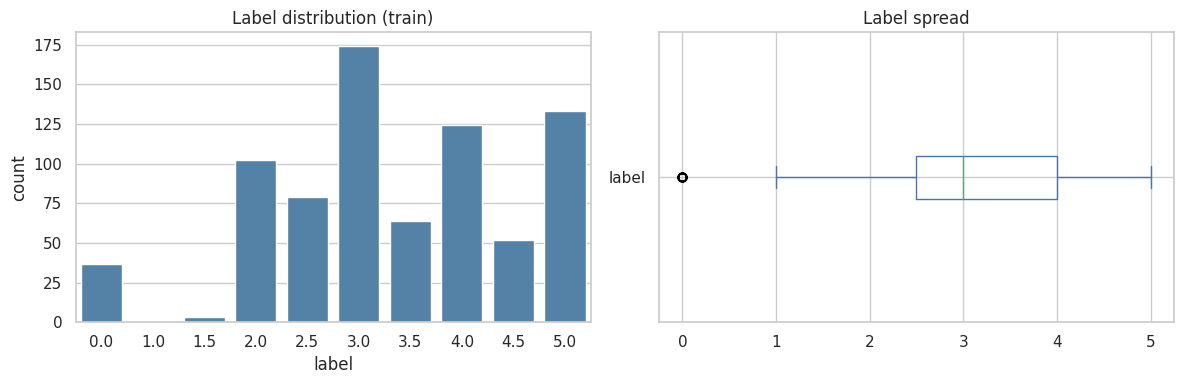

count    769.000
mean       3.313
std        1.239
min        0.000
25%        2.500
50%        3.000
75%        4.000
max        5.000
Name: label, dtype: float64
Baseline RMSE (predict the mean): 1.2382


In [3]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x="label", data=train, ax=ax[0], color="steelblue"); ax[0].set_title("Label distribution (train)")
train["label"].plot.box(ax=ax[1], vert=False); ax[1].set_title("Label spread")
plt.tight_layout(); plt.show()
BASE_RMSE = float(np.sqrt(((y - y.mean())**2).mean()))
print(train["label"].describe().round(3)); print("Baseline RMSE (predict the mean):", round(BASE_RMSE, 4))

## 3. Transcription (Whisper, native long-form generation)
Whisper-small transcribes each 45–60 s clip with its native long-form `generate()` path. Transcripts are cached keyed by **(split, filename)** because train and test share file names. Fallback decoding uses sampling, so the random seed is fixed.

In [4]:
from transformers import AutoProcessor, WhisperForConditionalGeneration
TRANSCRIPT_CACHE = "transcripts_whisper_native_v3.csv"

def load_audio(path):
    y_, _ = librosa.load(path, sr=SR, mono=True)
    return y_

def transcribe_all(df, model_name="openai/whisper-small", batch_size=2):
    processor = AutoProcessor.from_pretrained(model_name)
    model = WhisperForConditionalGeneration.from_pretrained(
        model_name, dtype=torch.float16 if GPU else torch.float32, low_cpu_mem_usage=True).to(dev_str).eval()
    device = torch.device(dev_str)
    torch.manual_seed(SEED)
    out, paths = [], df["path"].tolist()
    for i in range(0, len(paths), batch_size):
        audios = [load_audio(p) for p in paths[i:i + batch_size]]
        inputs = processor(audios, sampling_rate=SR, return_tensors="pt", truncation=False,
                           padding="longest", return_attention_mask=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        if GPU: inputs["input_features"] = inputs["input_features"].to(dtype=torch.float16)
        with torch.inference_mode():
            ids = model.generate(**inputs, language="en", task="transcribe", return_timestamps=True,
                                 condition_on_prev_tokens=True, compression_ratio_threshold=1.35,
                                 logprob_threshold=-1.0, no_speech_threshold=0.6,
                                 temperature=(0.0, 0.2, 0.4, 0.6, 0.8, 1.0))
        out.extend(t.strip() for t in processor.batch_decode(ids, skip_special_tokens=True, clean_up_tokenization_spaces=False))
        if (i // batch_size) % 25 == 0: print(f"{min(i + batch_size, len(paths))}/{len(paths)}", end=" | ", flush=True)
    del model, processor
    if GPU: torch.cuda.empty_cache()
    return out

tr_cache = load_csv_cache(TRANSCRIPT_CACHE, len(all_df))
if tr_cache is not None and {"split", "filename", "transcript"}.issubset(tr_cache.columns):
    print("Using cached transcripts:", cache_path(TRANSCRIPT_CACHE))
    all_df = all_df.merge(tr_cache.fillna("")[["split", "filename", "transcript"]], on=["split", "filename"], how="left", validate="one_to_one")
    assert len(all_df) == tr_mask.size and all_df.transcript.notna().all(), "transcript merge failed"
else:
    t0 = time.time()
    all_df["transcript"] = transcribe_all(all_df)
    all_df[["split", "filename", "transcript"]].to_csv(os.path.join(WORK, TRANSCRIPT_CACHE), index=False)
    print(f"\nWhisper ASR done in {(time.time()-t0)/60:.1f} min")
all_df["transcript"] = all_df["transcript"].fillna("")
assert (all_df.split.values == np.where(tr_mask, "train", "test")).all()
TXT_HASH = hashlib.md5("\n".join(all_df.transcript).encode("utf-8")).hexdigest()[:8]   # keys all transcript-dependent caches
print("transcript fingerprint:", TXT_HASH)
all_df.sample(4, random_state=SEED)[["split", "filename", "label", "transcript"]]

Using cached transcripts: /kaggle/input/datasets/piyushshx/transcriptsv3/transcripts_whisper_native_v3.csv
transcript fingerprint: fe6bc6bc


,split,filename,label,transcript
613,train,audio_25.wav,3.0,we went to a resort last summer with my family...
451,train,audio_577.wav,4.0,So my favorite plus is nature. The best place ...
731,train,audio_86.wav,2.0,"Yeah, there was a scene in the crowded market ..."
436,train,audio_237.wav,3.0,The playground is composed of students who are...


## 4. Handcrafted features
**Text statistics** (length, lexical diversity, sentence structure, fillers, subordinators), **repetition / hallucination signals** (compression ratio, repeated n-grams — ASR can loop on unintelligible speech), **audio statistics** (speaking rate, pauses), **GPT-2 perplexity**, **LanguageTool** grammar errors and **spaCy** syntax. Caches are keyed by the transcript fingerprint so they can never be stale.

In [5]:
FILLERS = {"um", "uh", "er", "ah", "erm", "hmm", "mm", "like"}
SUBORD = {"because", "although", "though", "while", "whereas", "since", "unless", "if", "when", "which", "who", "whom",
          "whose", "that", "where", "however", "therefore", "moreover", "furthermore", "but", "so", "and", "or"}
AUX = {"is", "are", "was", "were", "be", "been", "being", "am", "have", "has", "had", "do", "does", "did",
       "will", "would", "can", "could", "should", "may", "might", "must"}

def split_sentences(text):
    s = [x.strip() for x in re.split(r"(?<=[.!?])\s+", text) if x.strip()]
    return s if s else ([text] if text.strip() else [])

def text_features(text):
    words = re.findall(r"[A-Za-z']+", text.lower()); n = len(words)
    sents = split_sentences(text)
    slen = np.array([len(re.findall(r"[A-Za-z']+", s)) for s in sents]) if sents else np.array([0])
    reps = sum(1 for a, b in zip(words, words[1:]) if a == b)
    tri = list(zip(words, words[1:], words[2:])); raw = text.encode("utf-8")
    run, best_run = 1, 1
    for a, b in zip(words, words[1:]):
        run = run + 1 if a == b else 1; best_run = max(best_run, run)
    return {
        "n_words": n, "n_unique": len(set(words)), "ttr": len(set(words)) / n if n else 0,
        "n_sents": len(sents), "avg_sent_len": slen.mean(), "std_sent_len": slen.std(), "max_sent_len": slen.max(),
        "short_sent_frac": (slen < 4).mean() if len(slen) else 1,
        "avg_word_len": np.mean([len(w) for w in words]) if n else 0,
        "long_word_frac": np.mean([len(w) >= 7 for w in words]) if n else 0,
        "filler_rate": sum(w in FILLERS for w in words) / n if n else 0,
        "repeat_rate": reps / n if n else 0, "max_word_run": best_run,
        "subord_rate": sum(w in SUBORD for w in words) / n if n else 0,
        "aux_rate": sum(w in AUX for w in words) / n if n else 0,
        "comma_rate": text.count(",") / n if n else 0,
        "ends_with_punct": float(text.strip()[-1:] in ".!?") if text.strip() else 0,
        "lower_start_sents": np.mean([s[0].islower() for s in sents]) if sents else 0,
        "compress_ratio": len(raw) / max(len(zlib.compress(raw)), 1) if raw else 0,
        "trigram_repeat": 1 - len(set(tri)) / len(tri) if tri else 0,
    }

def audio_features(path):
    y_ = load_audio(path); dur = len(y_) / SR
    iv = librosa.effects.split(y_, top_db=30)
    speech = sum(e - s for s, e in iv) / SR
    return {"duration": dur, "speech_time": speech, "pause_ratio": 1 - speech / dur if dur else 0, "n_segments": len(iv)}

BASIC = load_csv_cache(f"feats_basic_{TXT_HASH}.csv", len(all_df))
if BASIC is None:
    t0 = time.time()
    TF = pd.DataFrame([text_features(t) for t in all_df.transcript])
    AF = pd.DataFrame([audio_features(p) for p in all_df.path])
    AF["wps"] = TF["n_words"] / AF["speech_time"].clip(lower=1)
    BASIC = pd.concat([TF, AF], axis=1); BASIC.to_csv(os.path.join(WORK, f"feats_basic_{TXT_HASH}.csv"), index=False)
    print(f"Basic features done in {time.time()-t0:.0f}s", BASIC.shape)
else:
    print("loaded cached basic features")

Basic features done in 148s (985, 25)


In [6]:
# ---- GPT-2 perplexity features ----
PF = load_csv_cache(f"feats_ppl_{TXT_HASH}.csv", len(all_df))
if PF is None:
    from transformers import AutoTokenizer, AutoModelForCausalLM
    gpt_tok = AutoTokenizer.from_pretrained("gpt2")
    gpt = AutoModelForCausalLM.from_pretrained("gpt2").to(dev_str).eval()

    @torch.no_grad()
    def sent_nll(sent):
        ids = gpt_tok(gpt_tok.bos_token + sent, return_tensors="pt", truncation=True, max_length=128).input_ids.to(gpt.device)
        if ids.shape[1] < 2: return np.nan
        return gpt(ids, labels=ids).loss.item()

    def ppl_features(text):
        nll = [x for x in (sent_nll(s) for s in split_sentences(text)) if not np.isnan(x)]
        if not nll: return {"nll_mean": np.nan, "nll_max": np.nan, "nll_std": np.nan, "nll_p75": np.nan}
        return {"nll_mean": np.mean(nll), "nll_max": np.max(nll), "nll_std": np.std(nll), "nll_p75": np.percentile(nll, 75)}

    t0 = time.time(); PF = pd.DataFrame([ppl_features(t) for t in all_df.transcript])
    PF.to_csv(os.path.join(WORK, f"feats_ppl_{TXT_HASH}.csv"), index=False)
    print(f"Perplexity features done in {time.time()-t0:.0f}s")
    del gpt
    if GPU: torch.cuda.empty_cache()
else:
    print("loaded cached perplexity features")

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Perplexity features done in 65s


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.2/63.2 kB 1.8 MB/s eta 0:00:00


LanguageTool:   0%|          | 0/985 [00:00<?, ?it/s]

LanguageTool done in 76s (985, 4)


spaCy:   0%|          | 0/985 [00:00<?, ?it/s]

spaCy done in 11s (985, 6)
Handcrafted feature matrix: (985, 39)


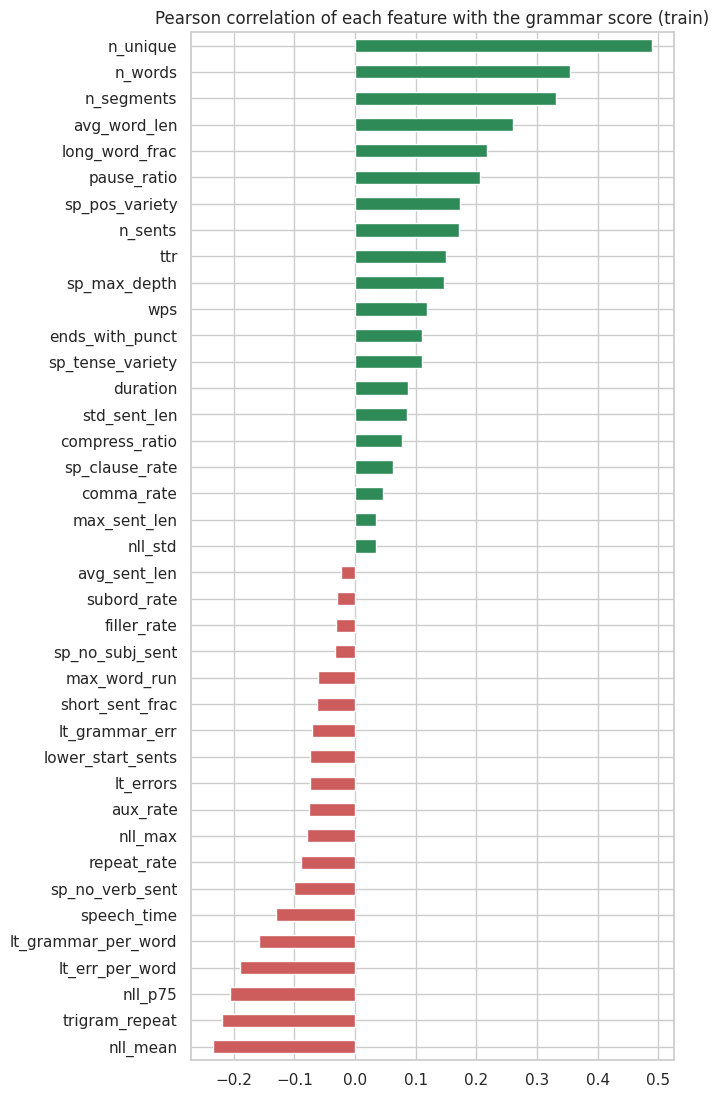

In [7]:
# ---- LanguageTool grammar errors + spaCy syntax (each part skipped safely if unavailable) ----
from tqdm.auto import tqdm
LT_F = load_csv_cache(f"feats_lt_{TXT_HASH}.csv", len(all_df))
if LT_F is None:
    try:
        t0 = time.time()
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "language_tool_python"], check=True, timeout=300)
        import language_tool_python
        tool = language_tool_python.LanguageTool("en-US")
        def lt_feats(t):
            m = tool.check(t) if t.strip() else []
            n = max(len(t.split()), 1)
            rid = lambda x: str(getattr(x, "rule_id", getattr(x, "ruleId", "")))
            cat = lambda x: str(getattr(x, "category", ""))
            grammar = [x for x in m if cat(x) in ("GRAMMAR", "TYPOS", "PUNCTUATION") or "GRAMMAR" in rid(x)]
            return {"lt_errors": len(m), "lt_err_per_word": len(m) / n, "lt_grammar_err": len(grammar), "lt_grammar_per_word": len(grammar) / n}
        LT_F = pd.DataFrame([lt_feats(t) for t in tqdm(all_df.transcript, desc="LanguageTool")]); tool.close()
        LT_F.to_csv(os.path.join(WORK, f"feats_lt_{TXT_HASH}.csv"), index=False); print(f"LanguageTool done in {time.time()-t0:.0f}s", LT_F.shape)
    except Exception as e:
        print("LanguageTool skipped:", repr(e)[:200]); LT_F = pd.DataFrame(index=all_df.index)
else:
    print("loaded cached LanguageTool features")

SP_F = load_csv_cache(f"feats_sp_{TXT_HASH}.csv", len(all_df))
if SP_F is None:
    try:
        t0 = time.time()
        import spacy
        try: nlp = spacy.load("en_core_web_sm")
        except OSError:
            subprocess.run([sys.executable, "-m", "spacy", "download", "en_core_web_sm"], check=True, timeout=300)
            nlp = spacy.load("en_core_web_sm")
        def depth(tok):
            d = 0
            while tok.head.i != tok.i:      # compare indices: the root is its own head
                tok = tok.head; d += 1
            return d
        def sp_feats(doc):
            sents = list(doc.sents); n = max(len(doc), 1)
            no_verb = np.mean([not any(tk.pos_ in ("VERB", "AUX") for tk in s) for s in sents]) if sents else 1
            no_subj = np.mean([not any(tk.dep_ in ("nsubj", "nsubjpass", "expl") for tk in s) for s in sents]) if sents else 1
            return {"sp_no_verb_sent": no_verb, "sp_no_subj_sent": no_subj,
                    "sp_clause_rate": sum(tk.dep_ in ("advcl", "ccomp", "relcl", "acl", "xcomp", "csubj") for tk in doc) / n,
                    "sp_max_depth": max([depth(tk) for tk in doc], default=0),
                    "sp_pos_variety": len({tk.pos_ for tk in doc}),
                    "sp_tense_variety": len({tk.morph.get("Tense")[0] for tk in doc if tk.morph.get("Tense")})}
        docs = nlp.pipe(all_df.transcript.tolist(), batch_size=32, disable=["ner", "lemmatizer"])
        SP_F = pd.DataFrame([sp_feats(d) for d in tqdm(docs, total=len(all_df), desc="spaCy")])
        SP_F.to_csv(os.path.join(WORK, f"feats_sp_{TXT_HASH}.csv"), index=False); print(f"spaCy done in {time.time()-t0:.0f}s", SP_F.shape)
    except Exception as e:
        print("spaCy skipped:", repr(e)[:200]); SP_F = pd.DataFrame(index=all_df.index)
else:
    print("loaded cached spaCy features")

FEATS = pd.concat([BASIC.reset_index(drop=True), PF.reset_index(drop=True), LT_F.reset_index(drop=True), SP_F.reset_index(drop=True)], axis=1)
FEATS = FEATS.replace([np.inf, -np.inf], np.nan)
print("Handcrafted feature matrix:", FEATS.shape)
corr = FEATS[tr_mask].apply(lambda c: np.corrcoef(c.fillna(c.median()), y)[0, 1]).sort_values()
plt.figure(figsize=(7, 0.26 * len(corr) + 1)); corr.plot.barh(color=np.where(corr > 0, "seagreen", "indianred"))
plt.title("Pearson correlation of each feature with the grammar score (train)"); plt.tight_layout(); plt.show()

## 5. Embeddings
**Text:** `all-mpnet-base-v2` sentence embeddings of the transcript.

**Audio (three views):** every view is a *statistical pooling* (temporal mean + standard deviation) of hidden states from three layers, so that both the average acoustic/linguistic content and its within-clip variability are retained.
- **WavLM-base-plus** (layers 4, 8, 12) — self-supervised speech model, strong on prosody and phonetics.
- **Whisper-small encoder** (layers 6, 9, 12) — trained for ASR, so its states are closer to *linguistic* content; clips are cut into 30 s windows and only the valid (non-padded) frames are pooled.
- **WavLM-large** (layers 8, 16, 24) — larger self-supervised model, a different view of the same signal.

Each extraction is cached (`.npy`) and reused automatically if present in `/kaggle/working` or an attached previous run.

In [8]:
from sentence_transformers import SentenceTransformer
texts = all_df.transcript.tolist()
EMB_MPNET = SentenceTransformer("sentence-transformers/all-mpnet-base-v2", device=dev_str).encode(
    texts, batch_size=32, normalize_embeddings=True, show_progress_bar=False)
print("Text embeddings:", EMB_MPNET.shape)
if GPU: torch.cuda.empty_cache()

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Text embeddings: (985, 768)


In [9]:
from transformers import AutoFeatureExtractor, AutoModel

def extract_ssl(model_name, layers, cache_name, desc):
    # mean+std pooled hidden states of a self-supervised speech model (WavLM family)
    cached = load_npy_cache(cache_name, len(all_df))
    if cached is not None:
        print(f"loaded cached {desc}:", cached.shape); return cached
    try:
        fe = AutoFeatureExtractor.from_pretrained(model_name)
        model = AutoModel.from_pretrained(model_name).to(dev_str).eval()
        rows, t0 = [], time.time()
        with torch.inference_mode():
            for p in tqdm(all_df.path, desc=desc):
                wav = load_audio(p)[: SR * 70]
                inp = fe(wav, sampling_rate=SR, return_tensors="pt").input_values.to(dev_str)
                if GPU:
                    with torch.autocast("cuda", dtype=torch.float16):
                        hs = model(inp, output_hidden_states=True).hidden_states
                else:
                    hs = model(inp, output_hidden_states=True).hidden_states
                pooled = []
                for l in layers:
                    h = hs[l].float().squeeze(0)
                    pooled += [h.mean(0), h.std(0, unbiased=False)]
                rows.append(torch.cat(pooled).cpu().numpy())
        E = np.stack(rows).astype(np.float32); np.save(os.path.join(WORK, cache_name), E)
        print(f"{desc} done in {(time.time()-t0)/60:.1f} min", E.shape)
        del model, fe
        if GPU: torch.cuda.empty_cache()
        return E
    except Exception as e:
        print(f"{desc} skipped:", repr(e)[:300]); return None

EMB_WAVLM_BASE = extract_ssl("microsoft/wavlm-base-plus", (4, 8, 12), "emb_wavlm_v3_meanstd.npy", "WavLM-base") if USE_WAVLM_BASE else None

preprocessor_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/2.23k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  378MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/248 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  378MB            

model.safetensors: downloading bytes:           |  0.00B            

WavLM-base:   0%|          | 0/985 [00:00<?, ?it/s]

WavLM-base done in 10.7 min (985, 4608)


In [10]:
def extract_whisper_encoder(cache_name="emb_whisper_enc_v4.npy", layers=(6, 9, 12)):
    cached = load_npy_cache(cache_name, len(all_df))
    if cached is not None:
        print("loaded cached Whisper-encoder embeddings:", cached.shape); return cached
    try:
        from transformers import WhisperFeatureExtractor, WhisperModel
        wfe = WhisperFeatureExtractor.from_pretrained("openai/whisper-small")
        enc = WhisperModel.from_pretrained("openai/whisper-small").encoder.to(dev_str).eval()
        CH, rows, t0 = SR * 30, [], time.time()
        with torch.inference_mode():
            for p in tqdm(all_df.path, desc="Whisper encoder"):
                wav = load_audio(p)
                chunks = [wav[i:i + CH] for i in range(0, len(wav), CH)]
                chunks = [c for c in chunks if len(c) >= SR] or [wav]            # drop a <1 s tail
                feats = wfe(chunks, sampling_rate=SR, return_tensors="pt").input_features.to(dev_str)
                if GPU:
                    with torch.autocast("cuda", dtype=torch.float16):
                        hs = enc(feats, output_hidden_states=True).hidden_states
                else:
                    hs = enc(feats, output_hidden_states=True).hidden_states
                valid = [max(1, min(1500, math.ceil(len(c) / 320))) for c in chunks]   # 50 encoder frames per second
                pooled = []
                for l in layers:
                    h = torch.cat([hs[l][j, :v].float() for j, v in enumerate(valid)], dim=0)   # valid frames only
                    pooled += [h.mean(0), h.std(0, unbiased=False)]
                rows.append(torch.cat(pooled).cpu().numpy())
        E = np.stack(rows).astype(np.float32); np.save(os.path.join(WORK, cache_name), E)
        print(f"Whisper-encoder embeddings done in {(time.time()-t0)/60:.1f} min", E.shape)
        del enc, wfe
        if GPU: torch.cuda.empty_cache()
        return E
    except Exception as e:
        print("Whisper-encoder embeddings skipped:", repr(e)[:300]); return None

EMB_WHISPER_ENC = extract_whisper_encoder() if USE_WHISPER_ENC else None

preprocessor_config.json:   0%|          | 0.00/185k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.97k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  967MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

Whisper encoder:   0%|          | 0/985 [00:00<?, ?it/s]

Whisper-encoder embeddings done in 1.4 min (985, 4608)


In [11]:
EMB_WAVLM_LARGE = extract_ssl("microsoft/wavlm-large", (8, 16, 24), "emb_wavlm_large_v4.npy", "WavLM-large") if USE_WAVLM_LARGE else None

AUDIO_VIEWS = {k: v for k, v in {"wavlm_base": EMB_WAVLM_BASE, "whisper_enc": EMB_WHISPER_ENC, "wavlm_large": EMB_WAVLM_LARGE}.items() if v is not None}
print("Audio views available:", {k: v.shape for k, v in AUDIO_VIEWS.items()})
assert AUDIO_VIEWS, "no audio view could be computed"

preprocessor_config.json:   0%|          | 0.00/214 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/2.22k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 1.26GB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/488 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.26GB            

model.safetensors: downloading bytes:           |  0.00B            

WavLM-large:   0%|          | 0/985 [00:00<?, ?it/s]

WavLM-large done in 19.1 min (985, 6144)
Audio views available: {'wavlm_base': (985, 4608), 'whisper_enc': (985, 4608), 'wavlm_large': (985, 6144)}


## 6. Cross-validation framework
All base models use the **same 5 stratified folds** (stratified on the half-point label). For every model we keep
(a) **out-of-fold (OOF)** predictions for honest evaluation and stacking, (b) the fold-averaged predictions on the test set, and
(c) the fold-averaged predictions on the training set (used only for the compulsory training-RMSE report).
Each model belongs to exactly one **group**, which the ablation in section 9 uses.

In [12]:
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import RidgeCV, LinearRegression
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr

K = 5
n_tr = int(tr_mask.sum())
folds = list(StratifiedKFold(n_splits=K, shuffle=True, random_state=SEED).split(np.zeros(n_tr), (y * 2).astype(int)))

def rmse(a, b): return float(np.sqrt(mean_squared_error(a, b)))
def score(a, b):
    b = np.clip(b, 0, 5); return rmse(a, b), float(pearsonr(a, b)[0])

BASE = {}   # name -> dict(oof, train, test, group)

def run_sklearn(name, make_model, X, group, verbose=True):
    Xtr, Xte = X[tr_mask], X[te_mask]
    oof, trp, tep = np.zeros(n_tr), np.zeros(n_tr), np.zeros(len(Xte))
    for a, b in folds:
        m = make_model().fit(Xtr[a], y[a])
        oof[b] = m.predict(Xtr[b]); trp += m.predict(Xtr) / K; tep += m.predict(Xte) / K
    BASE[name] = {"oof": oof, "train": trp, "test": tep, "group": group}
    r, p = score(y, oof)
    if verbose: print(f"{name:42s} CV RMSE={r:.4f}  Pearson={p:.4f}")
    return r

X_feats = FEATS.values.astype(float)
ALPHAS_AUDIO = np.logspace(2, 6, 14)

In [13]:
# ---- text-side and feature models ----
run_sklearn("GB - handcrafted features",
            lambda: HistGradientBoostingRegressor(max_depth=4, learning_rate=0.04, max_iter=400, l2_regularization=1.0,
                                                  min_samples_leaf=15, random_state=SEED), X_feats, "features")
run_sklearn("Ridge - features + MPNet emb",
            lambda: make_pipeline(SimpleImputer(strategy="median"), StandardScaler(), RidgeCV(alphas=np.logspace(1, 4, 12))),
            np.hstack([X_feats, EMB_MPNET]), "text")
run_sklearn("SVR - MPNet text emb",
            lambda: make_pipeline(StandardScaler(), SVR(C=3.0, epsilon=0.15, gamma="scale")), EMB_MPNET, "text")

# ---- one Ridge and one SVR head per audio view ----
for view, E in AUDIO_VIEWS.items():
    run_sklearn(f"Ridge - {view} emb", lambda: make_pipeline(StandardScaler(), RidgeCV(alphas=ALPHAS_AUDIO)), E, f"audio_{view}")
    run_sklearn(f"SVR - {view} emb", lambda: make_pipeline(StandardScaler(), SVR(C=3.0, epsilon=0.15, gamma="scale")), E, f"audio_{view}")

# ---- all audio views concatenated: each block standardised and rescaled to equal total weight ----
if len(AUDIO_VIEWS) >= 2:
    blocks = list(AUDIO_VIEWS.values()); dims = [b.shape[1] for b in blocks]
    X_audio_all = np.hstack(blocks); edges = np.cumsum([0] + dims)
    def make_all_audio_ridge():
        ct = ColumnTransformer([(f"v{i}", make_pipeline(StandardScaler(), FunctionTransformer(lambda X, s=math.sqrt(max(dims) / d): X * s)),
                                 slice(int(edges[i]), int(edges[i + 1]))) for i, d in enumerate(dims)])
        return make_pipeline(ct, RidgeCV(alphas=ALPHAS_AUDIO))
    run_sklearn("Ridge - all audio views", make_all_audio_ridge, X_audio_all, "audio_combined")

GB - handcrafted features                  CV RMSE=0.8381  Pearson=0.7370
Ridge - features + MPNet emb               CV RMSE=0.8750  Pearson=0.7077
SVR - MPNet text emb                       CV RMSE=0.9848  Pearson=0.6068
Ridge - wavlm_base emb                     CV RMSE=0.5469  Pearson=0.8973
SVR - wavlm_base emb                       CV RMSE=0.5511  Pearson=0.8971
Ridge - whisper_enc emb                    CV RMSE=0.5446  Pearson=0.8988
SVR - whisper_enc emb                      CV RMSE=0.5478  Pearson=0.9019
Ridge - wavlm_large emb                    CV RMSE=0.5114  Pearson=0.9109
SVR - wavlm_large emb                      CV RMSE=0.5295  Pearson=0.9072
Ridge - all audio views                    CV RMSE=0.5156  Pearson=0.9094


### 6.1 Multimodal Ridge (features + audio + text) with fold-safe preprocessing
Each block is imputed/standardised **inside every fold**. The text block is used as **raw unit-norm embeddings × weight** (standardising them would make them ~25× heavier than intended and let the weakest modality dominate the shared Ridge penalty). The two block weights are chosen from a small grid by CV; the grid is deliberately tiny to avoid optimistic selection.

In [14]:
base_audio = AUDIO_VIEWS.get("wavlm_base", next(iter(AUDIO_VIEWS.values())))
f_end = X_feats.shape[1]; a_end = f_end + base_audio.shape[1]
X_multi = np.hstack([X_feats, base_audio, EMB_MPNET])

def make_multimodal_ridge(w_audio=0.25, w_text=3.0):
    pre = ColumnTransformer([
        ("features", make_pipeline(SimpleImputer(strategy="median"), StandardScaler()), slice(0, f_end)),
        ("audio", make_pipeline(SimpleImputer(strategy="median"), StandardScaler(),
                                FunctionTransformer(lambda X, w=w_audio: X * w)), slice(f_end, a_end)),
        ("text", FunctionTransformer(lambda X, w=w_text: X * w), slice(a_end, X_multi.shape[1])),
    ])
    return make_pipeline(pre, RidgeCV(alphas=np.logspace(1, 4, 12)))

def cv_rmse(make_model, X):
    Xtr = X[tr_mask]; oof = np.zeros(n_tr)
    for a, b in folds: oof[b] = make_model().fit(Xtr[a], y[a]).predict(Xtr[b])
    return score(y, oof)[0]

grid = [(wa, wt) for wa in (0.15, 0.25, 0.4) for wt in (1.0, 3.0)]
sweep = pd.Series({f"w_audio={g[0]}, w_text={g[1]}": cv_rmse(lambda g=g: make_multimodal_ridge(*g), X_multi) for g in grid})
print(sweep.round(4).to_string())
best_w = grid[int(np.argmin(sweep.values))]; print("selected (w_audio, w_text):", best_w)
run_sklearn("Ridge - features + audio + text", lambda: make_multimodal_ridge(*best_w), X_multi, "multimodal")

w_audio=0.15, w_text=1.0    0.5329
w_audio=0.15, w_text=3.0    0.5365
w_audio=0.25, w_text=1.0    0.5340
w_audio=0.25, w_text=3.0    0.5275
w_audio=0.4, w_text=1.0     0.5312
w_audio=0.4, w_text=3.0     0.5269
selected (w_audio, w_text): (0.4, 3.0)
Ridge - features + audio + text            CV RMSE=0.5269  Pearson=0.9052


0.5268952188386038

## 7. Fine-tuned transformer on transcripts
DeBERTa-v3-base (falls back to RoBERTa-base if its tokenizer cannot load) with mean pooling and a regression head, fine-tuned per fold on the standardised score (MSE loss, mixed precision, 4 epochs). It uses the same folds as every other model; predictions are cached by transcript fingerprint so a rerun does not repeat the ~6 minutes.

In [15]:
FT_NAME = None
FT_CACHE = f"ft_preds_{TXT_HASH}.npz"
cached_ft = None
p_ft = cache_path(FT_CACHE)
if USE_FINETUNE and p_ft is not None:
    try:
        z = np.load(p_ft, allow_pickle=True)
        if z["oof"].shape[0] == n_tr and z["test"].shape[0] == int(te_mask.sum()):
            cached_ft = z; FT_NAME = str(z["name"]); print("loaded cached fine-tuned predictions:", FT_NAME)
    except Exception as e:
        print("fine-tune cache unreadable:", repr(e)[:100])

if cached_ft is not None:
    BASE[f"Fine-tuned {FT_NAME.split('/')[-1]}"] = {"oof": cached_ft["oof"], "train": cached_ft["train"], "test": cached_ft["test"], "group": "finetune"}
    print("Fine-tuned CV RMSE=%.4f  Pearson=%.4f" % score(y, cached_ft["oof"]))
elif USE_FINETUNE and GPU:
    import torch.nn as nn
    from transformers import AutoTokenizer, get_linear_schedule_with_warmup
    tok = None
    for cand in ("microsoft/deberta-v3-base", "roberta-base"):
        try:
            tok = AutoTokenizer.from_pretrained(cand); FT_NAME = cand; break
        except Exception as e:
            print("tokenizer failed for", cand, repr(e)[:120])
    print("Fine-tuning backbone:", FT_NAME)

    if FT_NAME:
        MAX_LEN, EPOCHS, BS, LR = 256, 4, 16, 3e-5
        enc = tok(texts, truncation=True, max_length=MAX_LEN, padding="max_length", return_tensors="pt")
        IDS, MASK = enc["input_ids"], enc["attention_mask"]
        tr_pos, te_pos = np.where(tr_mask)[0], np.where(te_mask)[0]
        y_mu, y_sd = y.mean(), y.std()

        class TextReg(nn.Module):
            def __init__(self, name):
                super().__init__()
                self.enc = AutoModel.from_pretrained(name); self.drop = nn.Dropout(0.1)
                self.head = nn.Linear(self.enc.config.hidden_size, 1)
            def forward(self, ids, mask):
                h = self.enc(input_ids=ids, attention_mask=mask).last_hidden_state
                m = mask.unsqueeze(-1).to(h.dtype)
                return self.head(self.drop((h * m).sum(1) / m.sum(1).clamp(min=1))).squeeze(-1)

        @torch.no_grad()
        def predict_rows(model, rows, bs=64):
            model.eval(); out = []
            for i in range(0, len(rows), bs):
                r = rows[i:i + bs]
                with torch.autocast("cuda", dtype=torch.float16):
                    out.append(model(IDS[r].cuda(), MASK[r].cuda()).float().cpu().numpy())
            return np.concatenate(out) * y_sd + y_mu

        oof, trp, tep = np.zeros(n_tr), np.zeros(n_tr), np.zeros(len(te_pos))
        t0 = time.time()
        for f, (a, b) in enumerate(folds):
            torch.manual_seed(SEED + f); rng = np.random.RandomState(SEED + f)
            model = TextReg(FT_NAME).cuda().float()
            opt = torch.optim.AdamW([{"params": model.enc.parameters(), "lr": LR}, {"params": model.head.parameters(), "lr": 1e-3}], weight_decay=0.01)
            steps = EPOCHS * math.ceil(len(a) / BS)
            sch = get_linear_schedule_with_warmup(opt, int(0.1 * steps), steps)
            scaler = torch.amp.GradScaler("cuda")
            yz = torch.tensor((y - y_mu) / y_sd, dtype=torch.float32)
            for ep in range(EPOCHS):
                model.train(); perm = rng.permutation(a)
                for i in range(0, len(perm), BS):
                    idx = perm[i:i + BS]; rows = tr_pos[idx]
                    with torch.autocast("cuda", dtype=torch.float16):
                        pred = model(IDS[rows].cuda(), MASK[rows].cuda())
                    loss = nn.functional.mse_loss(pred.float(), yz[idx].cuda())
                    opt.zero_grad(set_to_none=True); scaler.scale(loss).backward(); scaler.unscale_(opt)
                    nn.utils.clip_grad_norm_(model.parameters(), 1.0); scaler.step(opt); scaler.update(); sch.step()
            oof[b] = predict_rows(model, tr_pos[b]); trp += predict_rows(model, tr_pos) / K; tep += predict_rows(model, te_pos) / K
            print(f"fold {f}: val RMSE={rmse(y[b], np.clip(oof[b], 0, 5)):.4f}  ({(time.time()-t0)/60:.1f} min)", flush=True)
            del model, opt; torch.cuda.empty_cache()
        BASE[f"Fine-tuned {FT_NAME.split('/')[-1]}"] = {"oof": oof, "train": trp, "test": tep, "group": "finetune"}
        np.savez(os.path.join(WORK, FT_CACHE), oof=oof, train=trp, test=tep, name=FT_NAME)
        print("Fine-tuned CV RMSE=%.4f  Pearson=%.4f" % score(y, oof))
else:
    print("Fine-tuning skipped.")

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model: reconstructing file:   0%|          |  0.00B / 2.46MB            

spm.model: downloading bytes:           |  0.00B            

Fine-tuning backbone: microsoft/deberta-v3-base


...

[transformers] DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
mask_predictions.dense.bias             | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


fold 3: val RMSE=0.8291  (5.0 min)


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
mask_predictions.dense.bias             | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


fold 4: val RMSE=0.7536  (6.2 min)
Fine-tuned CV RMSE=0.7798  Pearson=0.7804


## 8. Stacking
A **non-negative linear regression** over the base models' OOF predictions: weights are ≥ 0 and the intercept/scale calibrate predictions that are shrunk toward the mean. Its own performance is estimated with *separately seeded* 5-fold CVs over the OOF matrix (averaged over three seeds), so the stacker is never scored on the data it was fitted to.

In [16]:
names = list(BASE)
groups = {n: BASE[n]["group"] for n in names}
P_oof = np.column_stack([BASE[n]["oof"] for n in names])
P_train = np.column_stack([BASE[n]["train"] for n in names])
P_test = np.column_stack([BASE[n]["test"] for n in names])

def stack_cv(cols, seeds=(11, 22, 33)):
    res = []
    for s in seeds:
        o = np.zeros(n_tr)
        for a, b in KFold(5, shuffle=True, random_state=s).split(P_oof):
            m = LinearRegression(positive=True).fit(P_oof[a][:, cols], y[a]); o[b] = m.predict(P_oof[b][:, cols])
        res.append(score(y, o))
    return tuple(np.mean(res, axis=0))

rows = []
for i, n in enumerate(names):
    r, p = score(y, P_oof[:, i]); rows.append({"model": n, "group": groups[n], "CV RMSE": r, "CV Pearson": p})
all_cols = list(range(len(names)))
r, p = stack_cv(all_cols); rows.append({"model": "STACK (all base models)", "group": "stack", "CV RMSE": r, "CV Pearson": p})
results = pd.DataFrame(rows)
display(results.round(4))

# Ablation: leave out one group at a time, plus "no audio-based model at all"
abl = []
for g in sorted(set(groups.values())):
    cols = [i for i, n in enumerate(names) if groups[n] != g]
    if cols: r, p = stack_cv(cols); abl.append({"variant": f"without {g}", "CV RMSE": r, "CV Pearson": p})
non_audio = [i for i, n in enumerate(names) if not groups[n].startswith(("audio", "multimodal"))]
if non_audio and len(non_audio) < len(names):
    r, p = stack_cv(non_audio); abl.append({"variant": "without ALL audio-based models", "CV RMSE": r, "CV Pearson": p})
audio_only = [i for i, n in enumerate(names) if groups[n].startswith("audio")]
if audio_only:
    r, p = stack_cv(audio_only); abl.append({"variant": "ONLY the audio_* heads", "CV RMSE": r, "CV Pearson": p})
abl = pd.DataFrame(abl); print("Ablation (stack variants):"); display(abl.round(4))

,model,group,CV RMSE,CV Pearson
0,GB - handcrafted features,features,0.8381,0.7370
1,Ridge - features + MPNet emb,text,0.8750,0.7077
2,SVR - MPNet text emb,text,0.9848,0.6068
3,Ridge - wavlm_base emb,audio_wavlm_base,0.5469,0.8973
4,SVR - wavlm_base emb,audio_wavlm_base,0.5511,0.8971
5,Ridge - whisper_enc emb,audio_whisper_enc,0.5446,0.8988
6,SVR - whisper_enc emb,audio_whisper_enc,0.5478,0.9019
7,Ridge - wavlm_large emb,audio_wavlm_large,0.5114,0.9109
8,SVR - wavlm_large emb,audio_wavlm_large,0.5295,0.9072
9,Ridge - all audio views,audio_combined,0.5156,0.9094


Ablation (stack variants):


,variant,CV RMSE,CV Pearson
0,without audio_combined,0.4779,0.9228
1,without audio_wavlm_base,0.4779,0.9228
2,without audio_wavlm_large,0.4855,0.9203
3,without audio_whisper_enc,0.4831,0.9210
4,without features,0.4775,0.9230
5,without finetune,0.4878,0.9195
6,without multimodal,0.4811,0.9217
7,without text,0.4766,0.9233
8,without ALL audio-based models,0.6893,0.8307
9,ONLY the audio_* heads,0.4934,0.9175


In [17]:
# ---- Final stacker, compulsory training RMSE, bootstrap CIs, submission ----
stacker = LinearRegression(positive=True).fit(P_oof, y)
w = pd.Series(stacker.coef_, index=names); print("Stacker weights:"); display(w.round(3).to_frame("weight")); print("intercept:", round(stacker.intercept_, 3))

train_pred = np.clip(stacker.predict(P_train), 0, 5)
test_pred = np.clip(stacker.predict(P_test), 0, 5)
oof_stack = np.zeros(n_tr)
for a, b in KFold(5, shuffle=True, random_state=11).split(P_oof):
    oof_stack[b] = LinearRegression(positive=True).fit(P_oof[a], y[a]).predict(P_oof[b])
oof_stack = np.clip(oof_stack, 0, 5)

TRAIN_RMSE, TRAIN_PEARSON = rmse(y, train_pred), float(pearsonr(y, train_pred)[0])
CV_RMSE, CV_PEARSON = results.loc[results.model.str.startswith("STACK"), ["CV RMSE", "CV Pearson"]].values[0]

def boot_ci(yt, yp, n=1000, seed=0):
    rng = np.random.RandomState(seed); idx = rng.randint(0, len(yt), (n, len(yt)))
    rm = np.array([rmse(yt[i], yp[i]) for i in idx]); pr = np.array([pearsonr(yt[i], yp[i])[0] for i in idx])
    return np.percentile(rm, [2.5, 97.5]), np.percentile(pr, [2.5, 97.5])
CI_RMSE, CI_PEARSON = boot_ci(y, oof_stack)

print("=" * 66)
print(f"TRAINING RMSE (final ensemble on the training clips) : {TRAIN_RMSE:.4f}")
print(f"Training Pearson                                    : {TRAIN_PEARSON:.4f}")
print(f"CV RMSE (out-of-fold, honest estimate)              : {CV_RMSE:.4f}   95% bootstrap CI [{CI_RMSE[0]:.3f}, {CI_RMSE[1]:.3f}]")
print(f"CV Pearson                                          : {CV_PEARSON:.4f}   95% bootstrap CI [{CI_PEARSON[0]:.3f}, {CI_PEARSON[1]:.3f}]")
print("=" * 66)
print("Note: model-to-model differences smaller than the CI width should not be over-interpreted.")

submission = pd.DataFrame({"filename": all_df.loc[te_mask, "filename"].values, "label": test_pred})
assert len(submission) == len(test) and (submission.filename.values == test.filename.values).all()
if "sample_submission.csv" in csv_paths:
    assert list(pd.read_csv(csv_paths["sample_submission.csv"], nrows=1).columns) == list(submission.columns), "submission columns differ from sample_submission.csv"
submission.to_csv(os.path.join(WORK, "submission.csv"), index=False)
print("Saved submission.csv", submission.shape); display(submission.head())

Stacker weights:


,weight
GB - handcrafted features,0.030
Ridge - features + MPNet emb,0.006
SVR - MPNet text emb,0.000
Ridge - wavlm_base emb,0.000
SVR - wavlm_base emb,0.000
Ridge - whisper_enc emb,0.000
SVR - whisper_enc emb,0.254
Ridge - wavlm_large emb,0.332
SVR - wavlm_large emb,0.109
Ridge - all audio views,0.000


intercept: -0.366
TRAINING RMSE (final ensemble on the training clips) : 0.1922
Training Pearson                                    : 0.9880
CV RMSE (out-of-fold, honest estimate)              : 0.4779   95% bootstrap CI [0.450, 0.504]
CV Pearson                                          : 0.9228   95% bootstrap CI [0.910, 0.935]
Note: model-to-model differences smaller than the CI width should not be over-interpreted.
Saved submission.csv (216, 2)


,filename,label
0,audio_128.wav,2.965753
1,audio_156.wav,4.206875
2,audio_19.wav,4.713217
3,audio_108.wav,2.005026
4,audio_206.wav,2.104432


## 9. Visualisations and interpretability

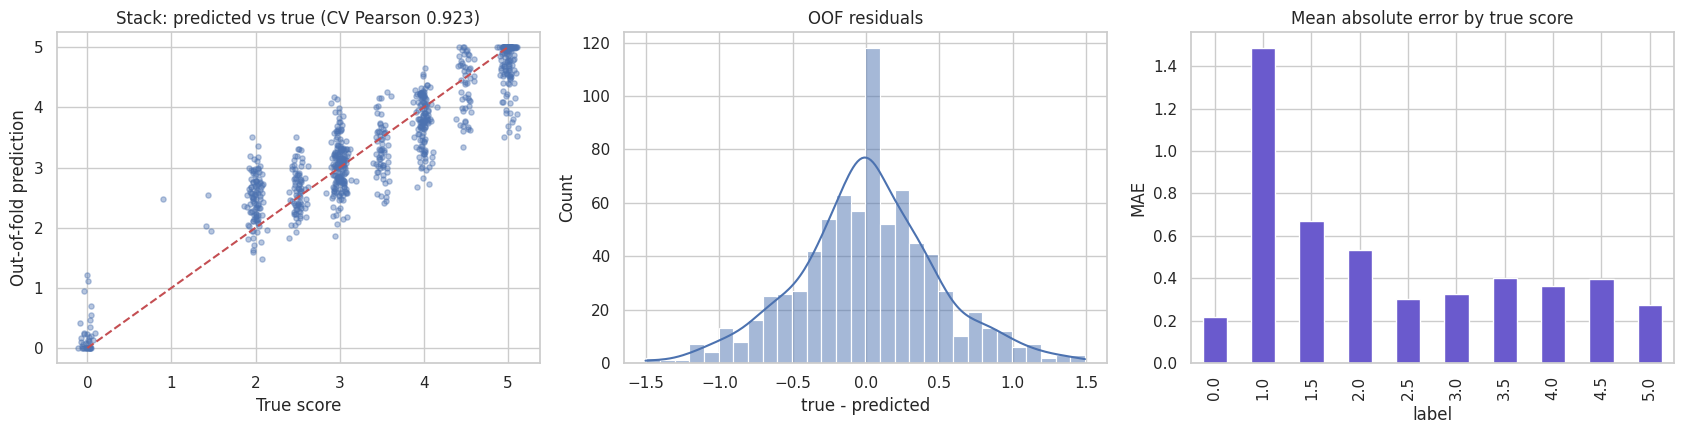

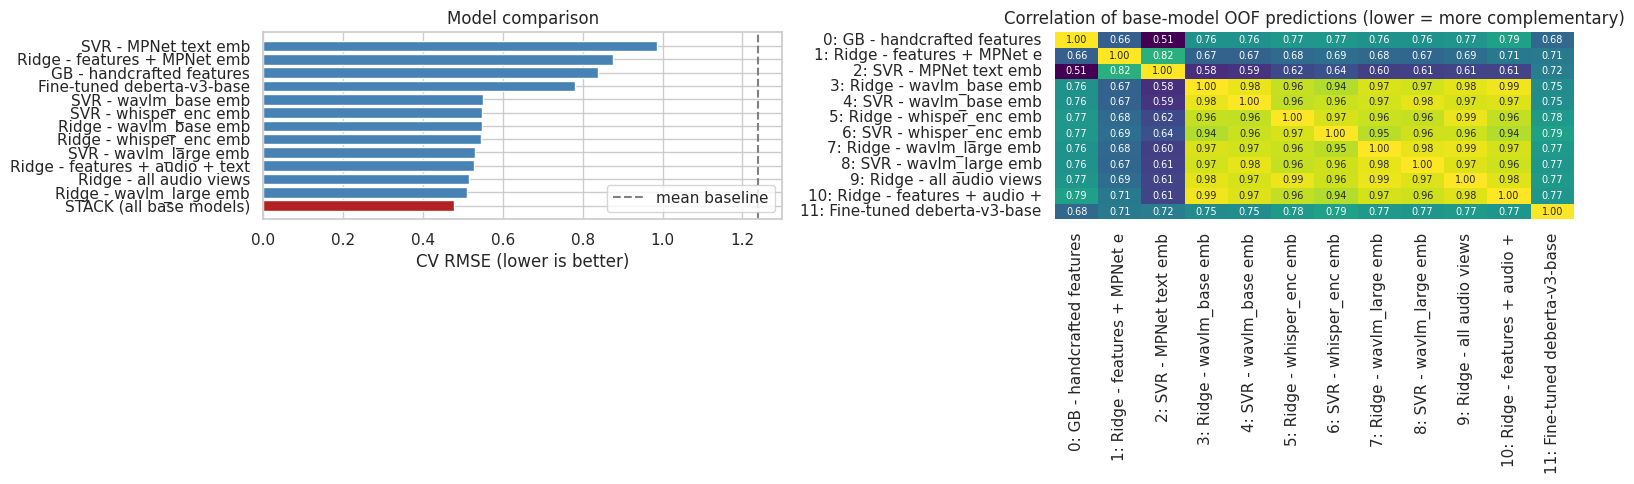

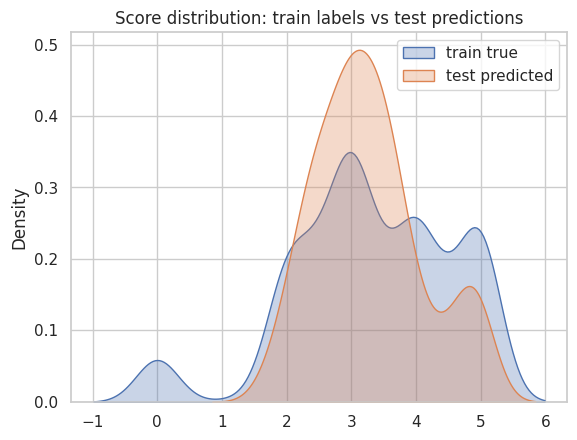

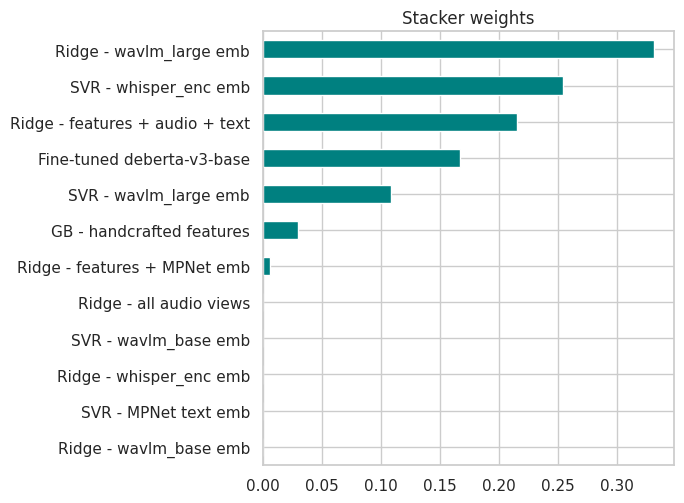

In [18]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))
ax[0].scatter(y + np.random.normal(0, 0.05, n_tr), oof_stack, alpha=0.4, s=14); ax[0].plot([0, 5], [0, 5], "r--")
ax[0].set_xlabel("True score"); ax[0].set_ylabel("Out-of-fold prediction"); ax[0].set_title(f"Stack: predicted vs true (CV Pearson {CV_PEARSON:.3f})")
res_ = y - oof_stack; sns.histplot(res_, bins=30, kde=True, ax=ax[1]); ax[1].set_title("OOF residuals"); ax[1].set_xlabel("true - predicted")
pd.DataFrame({"label": y, "err": np.abs(res_)}).groupby("label")["err"].mean().plot.bar(ax=ax[2], color="slateblue")
ax[2].set_title("Mean absolute error by true score"); ax[2].set_ylabel("MAE")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(1, 2, figsize=(16, 5))
rs = results.sort_values("CV RMSE")
ax[0].barh(rs.model, rs["CV RMSE"], color=["firebrick" if m.startswith("STACK") else "steelblue" for m in rs.model])
ax[0].axvline(BASE_RMSE, color="gray", ls="--", label="mean baseline"); ax[0].set_xlabel("CV RMSE (lower is better)"); ax[0].set_title("Model comparison"); ax[0].legend()
short = [f"{i}: {n[:26]}" for i, n in enumerate(names)]
sns.heatmap(pd.DataFrame(P_oof, columns=short).corr(), annot=True, fmt=".2f", annot_kws={"size": 7}, cmap="viridis", ax=ax[1], cbar=False)
ax[1].set_title("Correlation of base-model OOF predictions (lower = more complementary)")
plt.tight_layout(); plt.show()

sns.kdeplot(y, label="train true", fill=True, alpha=.3); sns.kdeplot(test_pred, label="test predicted", fill=True, alpha=.3)
plt.title("Score distribution: train labels vs test predictions"); plt.legend(); plt.show()
w.sort_values().plot.barh(figsize=(7, 0.35 * len(w) + 1), color="teal"); plt.title("Stacker weights"); plt.tight_layout(); plt.show()

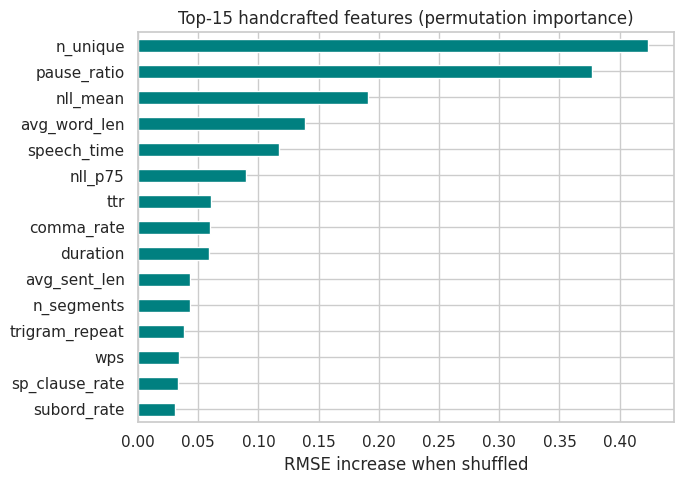

Largest out-of-fold errors:


,filename,true,pred,transcript,abs_err
162,audio_128.wav,2.0,3.50,Staying at a resort is a relaxing and enjoyabl...,1.50
361,audio_555.wav,5.0,3.51,I'm gonna describe the scene of a crowded mark...,1.49
423,audio_108.wav,1.0,2.49,As a young child one of the most exciting plac...,1.49
226,audio_357.wav,5.0,3.53,There were slides and monkey bars and swing se...,1.47
724,audio_91.wav,5.0,3.60,Imagine a vibrant marketplace in vanilla bustl...,1.40
308,audio_321.wav,2.0,3.35,"Well, my favorite hobby, I can say my favorite...",1.35


In [19]:
from sklearn.inspection import permutation_importance
gb_m = HistGradientBoostingRegressor(max_depth=4, learning_rate=0.04, max_iter=400, l2_regularization=1.0, min_samples_leaf=15,
                                     random_state=SEED).fit(X_feats[tr_mask], y)
pi = permutation_importance(gb_m, X_feats[tr_mask], y, n_repeats=8, random_state=SEED, scoring="neg_root_mean_squared_error")
imp = pd.Series(pi.importances_mean, index=FEATS.columns).sort_values().tail(15)
plt.figure(figsize=(7, 5)); imp.plot.barh(color="teal"); plt.title("Top-15 handcrafted features (permutation importance)")
plt.xlabel("RMSE increase when shuffled"); plt.tight_layout(); plt.show()

bad = pd.DataFrame({"filename": all_df.loc[tr_mask, "filename"].values, "true": y, "pred": oof_stack.round(2),
                    "transcript": all_df.loc[tr_mask, "transcript"].str[:160].values})
bad["abs_err"] = (bad.true - bad.pred).abs()
print("Largest out-of-fold errors:"); display(bad.sort_values("abs_err", ascending=False).head(6))

## 10. Development history
| Version | Main change | CV RMSE | CV Pearson | Leaderboard |
|---|---|---|---|---|
| v1 | Whisper transcript → handcrafted features + MiniLM, GB + Ridge | 0.790 | 0.772 | 0.4977 |
| v2 | + WavLM audio embeddings, fine-tuned DeBERTa, stacking | 0.4954 | 0.9168 | 0.3738 |
| v3 | native Whisper long-form ASR (2× faster), mean+std WavLM pooling, fold-safe Ridge (text over-weighted) | 0.5016 | 0.9145 | not submitted |
| v4 | fixed Ridge weights, two more audio views, clean ablations, bootstrap CIs | *see results below* | | |

*Leaderboard score = the competition's metric, which is on a different scale from plain CV RMSE.*

## 11. Report

In [20]:
tbl = "\n".join(f"| {r.model} | {r['group']} | {r['CV RMSE']:.4f} | {r['CV Pearson']:.4f} |" for _, r in results.iterrows())
abl_tbl = "\n".join(f"| {r['variant']} | {r['CV RMSE']:.4f} | {r['CV Pearson']:.4f} |" for _, r in abl.iterrows())
wt_tbl = "\n".join(f"| {n} | {v:.3f} |" for n, v in w.items())
views = ", ".join(f"{k} ({v.shape[1]} dims)" for k, v in AUDIO_VIEWS.items())
display(Markdown(f'''
### Pipeline
`audio → 16 kHz mono → (a) Whisper-small transcript → {FEATS.shape[1]} handcrafted features (text, repetition, audio, GPT-2 perplexity, LanguageTool, spaCy), MPNet embeddings{', fine-tuned ' + FT_NAME.split('/')[-1] if FT_NAME else ''}  |  (b) audio views: {views} → {len(names)} base models (GB, Ridge, SVR{', transformer' if FT_NAME else ''}) on shared 5-fold CV → non-negative linear stacker (blend + calibration) → clip to [0, 5]`

### Key results
| Metric | Value |
|---|---|
| **Training RMSE (final ensemble, training clips)** | **{TRAIN_RMSE:.4f}** |
| Training Pearson | {TRAIN_PEARSON:.4f} |
| **CV RMSE (out-of-fold)** | **{CV_RMSE:.4f}** (95% bootstrap CI {CI_RMSE[0]:.3f}–{CI_RMSE[1]:.3f}) |
| **CV Pearson** | **{CV_PEARSON:.4f}** (95% bootstrap CI {CI_PEARSON[0]:.3f}–{CI_PEARSON[1]:.3f}) |
| Baseline RMSE (predict the mean) | {BASE_RMSE:.4f} |

*Training RMSE note:* base-model training predictions are averages of the five fold models (each saw 80% of the training clips) passed through the final stacker, so it is a mildly optimistic in-sample figure. The CV numbers are the honest estimate of generalisation.

### Per-model CV results
| Model | Group | CV RMSE | CV Pearson |
|---|---|---|---|
{tbl}

### Ablation (what each model group contributes to the stack)
| Stack variant | CV RMSE | CV Pearson |
|---|---|---|
{abl_tbl}

### Stacker weights
| Model | Weight |
|---|---|
{wt_tbl}

intercept = {stacker.intercept_:.3f}

### Design decisions
- **Shared folds** for every model, so OOF predictions can be stacked without leakage; the stacker is itself evaluated by separately seeded CV.
- **Train and test share file names**, so audio paths and the transcript cache are keyed by *(split, filename)*; transcript-dependent caches also carry a transcript fingerprint, so features can never be stale.
- **Disfluencies are kept** in transcripts (fillers, repetitions, false starts) because they carry information about grammatical control; repetition features flag ASR loops on unintelligible clips.
- **Three audio views** (WavLM-base, Whisper-encoder, WavLM-large) because the ablation showed that audio carries most of the signal and different models capture different cues.
- **Multimodal Ridge block weights** are fitted per fold and chosen from a tiny CV grid; text enters as raw embeddings so the weakest modality cannot dominate the shared ridge penalty.
- **Non-negative linear stacker** limits overfitting with 769 samples and recalibrates scores that are shrunk toward the mean.

### Limitations and next steps
- Labels are subjective half-point MOS ratings, which sets a noise floor on RMSE; bootstrap intervals show how much of any difference is within noise.
- ASR normalises or mis-transcribes some speaker errors, so grammar mistakes can be lost before the text models see them; audio views partly compensate.
- Predictions remain slightly shrunk at the extremes (scores 0–1 and 5).
- Further ideas: layer-by-layer probing of the audio models, multi-seed fine-tuning, fine-tuning an audio encoder end to end, LLM-based rubric scoring as an extra feature.
'''))


### Pipeline
`audio → 16 kHz mono → (a) Whisper-small transcript → 39 handcrafted features (text, repetition, audio, GPT-2 perplexity, LanguageTool, spaCy), MPNet embeddings, fine-tuned deberta-v3-base  |  (b) audio views: wavlm_base (4608 dims), whisper_enc (4608 dims), wavlm_large (6144 dims) → 12 base models (GB, Ridge, SVR, transformer) on shared 5-fold CV → non-negative linear stacker (blend + calibration) → clip to [0, 5]`

### Key results
| Metric | Value |
|---|---|
| **Training RMSE (final ensemble, training clips)** | **0.1922** |
| Training Pearson | 0.9880 |
| **CV RMSE (out-of-fold)** | **0.4779** (95% bootstrap CI 0.450–0.504) |
| **CV Pearson** | **0.9228** (95% bootstrap CI 0.910–0.935) |
| Baseline RMSE (predict the mean) | 1.2382 |

*Training RMSE note:* base-model training predictions are averages of the five fold models (each saw 80% of the training clips) passed through the final stacker, so it is a mildly optimistic in-sample figure. The CV numbers are the honest estimate of generalisation.

### Per-model CV results
| Model | Group | CV RMSE | CV Pearson |
|---|---|---|---|
| GB - handcrafted features | features | 0.8381 | 0.7370 |
| Ridge - features + MPNet emb | text | 0.8750 | 0.7077 |
| SVR - MPNet text emb | text | 0.9848 | 0.6068 |
| Ridge - wavlm_base emb | audio_wavlm_base | 0.5469 | 0.8973 |
| SVR - wavlm_base emb | audio_wavlm_base | 0.5511 | 0.8971 |
| Ridge - whisper_enc emb | audio_whisper_enc | 0.5446 | 0.8988 |
| SVR - whisper_enc emb | audio_whisper_enc | 0.5478 | 0.9019 |
| Ridge - wavlm_large emb | audio_wavlm_large | 0.5114 | 0.9109 |
| SVR - wavlm_large emb | audio_wavlm_large | 0.5295 | 0.9072 |
| Ridge - all audio views | audio_combined | 0.5156 | 0.9094 |
| Ridge - features + audio + text | multimodal | 0.5269 | 0.9052 |
| Fine-tuned deberta-v3-base | finetune | 0.7798 | 0.7804 |
| STACK (all base models) | stack | 0.4779 | 0.9228 |

### Ablation (what each model group contributes to the stack)
| Stack variant | CV RMSE | CV Pearson |
|---|---|---|
| without audio_combined | 0.4779 | 0.9228 |
| without audio_wavlm_base | 0.4779 | 0.9228 |
| without audio_wavlm_large | 0.4855 | 0.9203 |
| without audio_whisper_enc | 0.4831 | 0.9210 |
| without features | 0.4775 | 0.9230 |
| without finetune | 0.4878 | 0.9195 |
| without multimodal | 0.4811 | 0.9217 |
| without text | 0.4766 | 0.9233 |
| without ALL audio-based models | 0.6893 | 0.8307 |
| ONLY the audio_* heads | 0.4934 | 0.9175 |

### Stacker weights
| Model | Weight |
|---|---|
| GB - handcrafted features | 0.030 |
| Ridge - features + MPNet emb | 0.006 |
| SVR - MPNet text emb | 0.000 |
| Ridge - wavlm_base emb | 0.000 |
| SVR - wavlm_base emb | 0.000 |
| Ridge - whisper_enc emb | 0.000 |
| SVR - whisper_enc emb | 0.254 |
| Ridge - wavlm_large emb | 0.332 |
| SVR - wavlm_large emb | 0.109 |
| Ridge - all audio views | 0.000 |
| Ridge - features + audio + text | 0.215 |
| Fine-tuned deberta-v3-base | 0.167 |

intercept = -0.366

### Design decisions
- **Shared folds** for every model, so OOF predictions can be stacked without leakage; the stacker is itself evaluated by separately seeded CV.
- **Train and test share file names**, so audio paths and the transcript cache are keyed by *(split, filename)*; transcript-dependent caches also carry a transcript fingerprint, so features can never be stale.
- **Disfluencies are kept** in transcripts (fillers, repetitions, false starts) because they carry information about grammatical control; repetition features flag ASR loops on unintelligible clips.
- **Three audio views** (WavLM-base, Whisper-encoder, WavLM-large) because the ablation showed that audio carries most of the signal and different models capture different cues.
- **Multimodal Ridge block weights** are fitted per fold and chosen from a tiny CV grid; text enters as raw embeddings so the weakest modality cannot dominate the shared ridge penalty.
- **Non-negative linear stacker** limits overfitting with 769 samples and recalibrates scores that are shrunk toward the mean.

### Limitations and next steps
- Labels are subjective half-point MOS ratings, which sets a noise floor on RMSE; bootstrap intervals show how much of any difference is within noise.
- ASR normalises or mis-transcribes some speaker errors, so grammar mistakes can be lost before the text models see them; audio views partly compensate.
- Predictions remain slightly shrunk at the extremes (scores 0–1 and 5).
- Further ideas: layer-by-layer probing of the audio models, multi-seed fine-tuning, fine-tuning an audio encoder end to end, LLM-based rubric scoring as an extra feature.
